In [30]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from loaders._gen_binary import generate_data

In [32]:
data = generate_data(seed=0, verbose=True)

Generated dataset with 1995 samples.
Shapes: [(1596, 25), (0, 25), (399, 25)]
Label distribution: Counter({np.int64(1): 817, np.int64(0): 779})
[WARNING] If you use a tree-based model, consider setting use_scaler=False.


In [33]:
X_train, y_train = data['train']
X_test, y_test = data['test']

Balanced Accuracy: 0.6842

Confusion Matrix:
[[141  59]
 [ 67 132]]


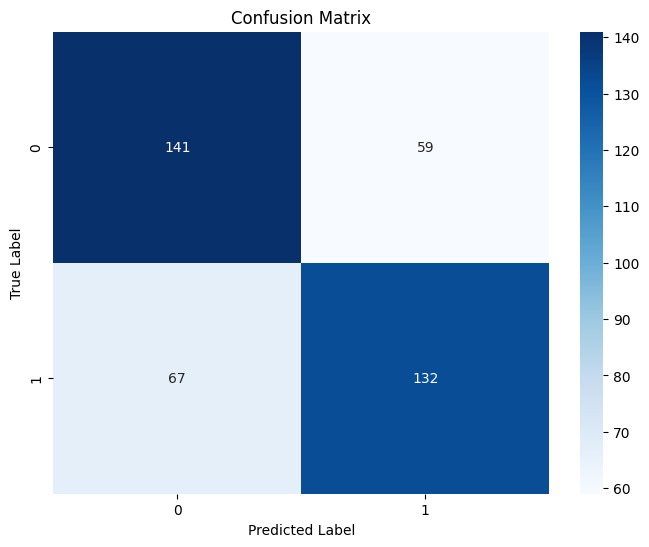

In [34]:
#Thử nghiệm với seed=0
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
import seaborn as sns

# Initialize Logistic Regression model with balanced class weights
lr_model = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000  # Increase max iterations to ensure convergence
)

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)

# Calculate metrics
bal_acc = balanced_accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Balanced Accuracy: {bal_acc:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [35]:
#Tính trung bình 30 seeds
bal_acc_scores = []

# Try different seeds
for seed in range(30):
    # Generate data with current seed
    data = generate_data(seed=seed, verbose=False)
    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    # Initialize and train model
    lr_model = LogisticRegression(
        random_state=42,
        class_weight='balanced',
        max_iter=1000
    )
    lr_model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = lr_model.predict(X_test)
    
    # Calculate and store balanced accuracy
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    bal_acc_scores.append(bal_acc)
    
    print(f"Seed {seed}: Balanced Accuracy = {bal_acc:.4f}")

# Calculate statistics
mean_acc = np.mean(bal_acc_scores)
std_acc = np.std(bal_acc_scores)

print(f"\nResults across {len(bal_acc_scores)} seeds:")
print(f"Mean Balanced Accuracy: {mean_acc:.4f}")
print(f"Standard Deviation: {std_acc:.4f}")


Seed 0: Balanced Accuracy = 0.6842
Seed 1: Balanced Accuracy = 0.6542
Seed 2: Balanced Accuracy = 0.6343
Seed 3: Balanced Accuracy = 0.6392
Seed 4: Balanced Accuracy = 0.6690
Seed 5: Balanced Accuracy = 0.6546
Seed 6: Balanced Accuracy = 0.6967
Seed 7: Balanced Accuracy = 0.6968
Seed 8: Balanced Accuracy = 0.7098
Seed 9: Balanced Accuracy = 0.6564
Seed 10: Balanced Accuracy = 0.6819
Seed 11: Balanced Accuracy = 0.6971
Seed 12: Balanced Accuracy = 0.6803
Seed 7: Balanced Accuracy = 0.6968
Seed 8: Balanced Accuracy = 0.7098
Seed 9: Balanced Accuracy = 0.6564
Seed 10: Balanced Accuracy = 0.6819
Seed 11: Balanced Accuracy = 0.6971
Seed 12: Balanced Accuracy = 0.6803
Seed 13: Balanced Accuracy = 0.6434
Seed 14: Balanced Accuracy = 0.6989
Seed 15: Balanced Accuracy = 0.6920
Seed 16: Balanced Accuracy = 0.6817
Seed 17: Balanced Accuracy = 0.6598
Seed 18: Balanced Accuracy = 0.6815
Seed 19: Balanced Accuracy = 0.6982
Seed 20: Balanced Accuracy = 0.6777
Seed 13: Balanced Accuracy = 0.6434
Seed 

In [36]:
#Chuẩn hóa + chọn lọc đặc trưng
from sklearn.feature_selection import mutual_info_classif, SelectKBest

# Parameters
n_features = 5
n_seeds = 30

# Lists to store results
bal_acc_scores = []
selected_features_count = {}  # To track frequency of selected features

# Process for each seed
for seed in range(n_seeds):
    # Generate data
    data = generate_data(seed=seed, verbose=False)
    X_train, y_train = data['train']
    X_test, y_test = data['test']

    
    # Select features using mutual information
    selector = SelectKBest(mutual_info_classif, k=n_features)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)
    
    # Track selected features
    selected_features = selector.get_support()
    for idx, is_selected in enumerate(selected_features):
        if is_selected:
            selected_features_count[idx] = selected_features_count.get(idx, 0) + 1
    
    # Train and evaluate model
    lr_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
    lr_model.fit(X_train_selected, y_train)
    y_pred = lr_model.predict(X_test_selected)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    bal_acc_scores.append(bal_acc)

# Calculate and print results
mean_acc = np.mean(bal_acc_scores)
std_acc = np.std(bal_acc_scores)

print(f"Performance Metrics:")
print(f"Mean Balanced Accuracy: {mean_acc:.4f}")
print(f"Standard Deviation: {std_acc:.4f}")

# Sort and print most frequently selected features
print("\nMost Frequently Selected Features:")
sorted_features = sorted(selected_features_count.items(), key=lambda x: x[1], reverse=True)
for feature_idx, count in sorted_features[:5]:
    print(f"Feature {feature_idx}: selected {count} times out of {n_seeds} runs")

Performance Metrics:
Mean Balanced Accuracy: 0.6844
Standard Deviation: 0.0218

Most Frequently Selected Features:
Feature 0: selected 30 times out of 30 runs
Feature 5: selected 30 times out of 30 runs
Feature 10: selected 30 times out of 30 runs
Feature 15: selected 30 times out of 30 runs
Feature 20: selected 30 times out of 30 runs


In [43]:
# Tạo 5 đặc trưng mới từ 25 đặc trưng cũ
def create_averaged_features(X):
    """
    Tạo 5 đặc trưng mới từ 25 đặc trưng ban đầu
    Feature mới i = mean(features [i, i+5, i+10, i+15, i+20])
    """
    n_samples, n_features = X.shape
    assert n_features == 25, f"Expected 25 features, got {n_features}"
    
    new_features = np.zeros((n_samples, 5))
    
    for i in range(5):
        # Lấy các indices cách nhau 5: i, i+5, i+10, i+15, i+20
        indices = [i + j*5 for j in range(5)]
        # Tính trung bình
        new_features[:, i] = np.mean(X[:, indices], axis=1)
    
    return new_features

In [56]:
bal_acc_scores = []

for i in range(30):
    X_train, y_train = generate_data(seed=i, verbose=False)['train']
    X_train_new = create_averaged_features(X_train)

    X_test, y_test = generate_data(seed=i, verbose=False)['test']
    X_test_new = create_averaged_features(X_test)

    # Huấn luyện mô hình và tính toán điểm số
    X_train_selected = np.column_stack([np.sin(X_train_new[:, 0]), X_train_new[:, 1]**2])
    X_test_selected = np.column_stack([np.sin(X_test_new[:, 0]), X_test_new[:, 1]**2])
    model = LogisticRegression()
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    bal_acc_scores.append(bal_acc)

print(np.mean(bal_acc_scores), np.std(bal_acc_scores))

0.6813118700311215 0.02408844358217284
